In [3]:
# %% Cell 0: Profiling (optional) and Imports
# %load_ext line_profiler # If you want to use %lprun for specific functions
# %load_ext memory_profiler # If you want to use %memit

# Use %%prun at the top of a cell you want to profile with cProfile
# Example:
# %%prun -s cumulative -q -l 15 -T profile_results.txt 
# (This would profile the entire cell's execution)

import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import logging # Good to have for messages from utils
from typing import Optional

# --- Add Project Root to sys.path ---
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR) 
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added project root to sys.path: {PROJECT_ROOT}")

# --- Import Custom Modules ---
from src.config_loader import MDetectorConfigAccessor # MODIFIED: Import accessor
from src.utils.validation_utils import (
    calculate_metrics_for_experiment_hdf5,    
    generate_roc_pr_data_gt_velocity_variant_hdf5, 
    load_config_from_hdf5 # Useful if you need to inspect a specific run's config
)
from src.visualization.metrics_plots import plot_roc_curve, plot_precision_recall_curve
from src.core.constants import OcclusionResult # For OcclusionResult.OCCLUDING_IMAGE.value

print("Cell 0: Imports and Paths - OK")

# %% Cell 1: Configuration and Path Setup

# --- Load Configuration using Accessor --- # MODIFIED
config_accessor: Optional[MDetectorConfigAccessor] = None
try:
    config_file_path = os.path.join(PROJECT_ROOT, 'config/m_detector_config.yaml')
    config_accessor = MDetectorConfigAccessor(config_file_path)
    print(f"Configuration loaded successfully using MDetectorConfigAccessor from: {config_file_path}")
except FileNotFoundError:
    print(f"ERROR: Config file not found at {config_file_path}. Cannot load default paths.")
except Exception as e:
    print(f"Error loading config with MDetectorConfigAccessor: {e}. Cannot load default paths.")

# --- Define Paths for GT Labels and M-Detector Outputs (HDF5) ---
# Use paths from config accessor as defaults, allow override if needed
default_gt_labels_dir = None
default_mdet_results_dir = None

if config_accessor:
    nuscenes_params = config_accessor.get_nuscenes_params()
    default_gt_labels_dir = nuscenes_params.get('label_path')
    if default_gt_labels_dir and not os.path.isabs(default_gt_labels_dir):
        default_gt_labels_dir = os.path.join(PROJECT_ROOT, default_gt_labels_dir)

    mdet_output_paths = config_accessor.get_mdetector_output_paths()
    default_mdet_results_dir = mdet_output_paths.get('save_path')
    if default_mdet_results_dir and not os.path.isabs(default_mdet_results_dir):
        default_mdet_results_dir = os.path.join(PROJECT_ROOT, default_mdet_results_dir)

# --- User-defined paths (can override defaults from config) ---
# These are the paths that will actually be used.
# If you want to use the config defaults, ensure these variables point to default_..._dir
# or that the hardcoded paths match your desired experimental output.

# Path to the directory containing your GT HDF5 files (e.g., gt_point_labels_scene-XXXX.h5)
GT_LABELS_BASE_DIR_HDF5 = default_gt_labels_dir if default_gt_labels_dir else "/home/drugge/staff-umbrella/TeamHolgerResearch/drugge/nuscenes_labels_interpolated_mini_test" # Fallback if not in config

# Path to the root directory of your M-Detector experiment results (containing scene-named HDF5 files like mdet_results_scene-XXXX.h5)
MDET_EXPERIMENT_DIR_HDF5 = default_mdet_results_dir if default_mdet_results_dir else "/home/drugge/staff-umbrella/TeamHolgerResearch/drugge/m_detector_output_mini_test" # Fallback

print(f"\nUsing M-Detector HDF5 Results From: {MDET_EXPERIMENT_DIR_HDF5}")
print(f"Using GT HDF5 Labels From:          {GT_LABELS_BASE_DIR_HDF5}")

if not os.path.isdir(MDET_EXPERIMENT_DIR_HDF5):
    print(f"WARNING: M-Detector results directory does not exist: {MDET_EXPERIMENT_DIR_HDF5}")
if not os.path.isdir(GT_LABELS_BASE_DIR_HDF5):
    print(f"WARNING: GT labels directory does not exist: {GT_LABELS_BASE_DIR_HDF5}")


# --- Base Evaluation Parameters ---
# These parameters define how the comparison between GT and M-Detector results is made.
base_eval_params = {
    "mdet_label_field_name": "mdet_label", # Field in MDet HDF5 holding the predicted label
    "mdet_dynamic_label_value": OcclusionResult.OCCLUDING_IMAGE.value, # Value indicating "dynamic" by MDet
    "coordinate_tolerance_for_verification": 1e-3, # Tolerance for matching points by coordinates
    
    # Default range parameters for filtering points before metric calculation.
    # These can be overridden if a scene's HDF5 M-Detector result file contains
    # its own run-specific config (which calculate_metrics_for_experiment_hdf5 tries to load).
    "mdet_min_point_range_meters": 1.0, # Fallback min range
    "mdet_max_point_range_meters": 50.0, # Fallback max range (matches your config)
}
# If you want to ensure these fallbacks also come from config:
if config_accessor:
    point_filter_params = config_accessor.get_point_pre_filtering_params()
    base_eval_params["mdet_min_point_range_meters"] = point_filter_params.get('min_range_meters', base_eval_params["mdet_min_point_range_meters"])
    base_eval_params["mdet_max_point_range_meters"] = point_filter_params.get('max_range_meters', base_eval_params["mdet_max_point_range_meters"])

print(f"\nBase Evaluation Parameters:")
for key, value in base_eval_params.items():
    print(f"  {key}: {value}")

print("\nCell 1: Configuration - OK")


Cell 0: Imports and Paths - OK
Configuration loaded successfully using MDetectorConfigAccessor from: /home/drugge/Unsupervised-Moving-Point-Detection/m_detector_python/config/m_detector_config.yaml

Using M-Detector HDF5 Results From: /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/m_detector_output_26_05
Using GT HDF5 Labels From:          /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/nuscenes_labels_interpolated

Base Evaluation Parameters:
  mdet_label_field_name: mdet_label
  mdet_dynamic_label_value: 0
  coordinate_tolerance_for_verification: 0.001
  mdet_min_point_range_meters: 2.5
  mdet_max_point_range_meters: 50.0

Cell 1: Configuration - OK


In [4]:


# %% Cell 2: Calculate Overall Summary Metrics 

# --- Parameters for this specific summary calculation ---
eval_params_for_summary = base_eval_params.copy()
# Define the GT velocity threshold to consider a GT point "truly dynamic" for this summary.
eval_params_for_summary["gt_velocity_threshold"] = 1.0 # m/s 

print(f"\nCalculating overall metrics with GT Velocity Threshold = {eval_params_for_summary['gt_velocity_threshold']:.2f} m/s...")

experiment_summary_hdf5 = calculate_metrics_for_experiment_hdf5( 
    mdet_experiment_dir=MDET_EXPERIMENT_DIR_HDF5,
    gt_labels_base_dir=GT_LABELS_BASE_DIR_HDF5,
    eval_params=eval_params_for_summary # Pass the combined and specific eval params
)

if experiment_summary_hdf5:
    print(f"\n--- Experiment Summary Metrics (HDF5, GT Vel Thresh = {eval_params_for_summary['gt_velocity_threshold']:.2f} m/s) ---")
    print(f"  File Format Used: {experiment_summary_hdf5.get('file_format_used', 'N/A')}")
    print(f"  Precision: {experiment_summary_hdf5.get('Precision', float('nan')):.4f}")
    print(f"  Recall:    {experiment_summary_hdf5.get('Recall', float('nan')):.4f}")
    print(f"  F1 Score:  {experiment_summary_hdf5.get('F1', float('nan')):.4f}")
    print(f"  IoU Dynamic: {experiment_summary_hdf5.get('overall_iou_dynamic', float('nan')):.4f}")
    print(f"  Accuracy:  {experiment_summary_hdf5.get('Accuracy', float('nan')):.4f}")
    print(f"  True Positives (Dynamic): {experiment_summary_hdf5.get('TP', 0)}")
    print(f"  False Positives (Dynamic): {experiment_summary_hdf5.get('FP', 0)}")
    print(f"  False Negatives (Dynamic): {experiment_summary_hdf5.get('FN', 0)}")
    print(f"  True Negatives (Static/Other): {experiment_summary_hdf5.get('TN', 0)}")
    print(f"  Scenes Evaluated: {experiment_summary_hdf5.get('num_scenes_successfully_evaluated', 0)}/{experiment_summary_hdf5.get('num_scenes_total_in_dir', 0)}")
    if experiment_summary_hdf5.get('scenes_with_errors', 0) > 0:
        print(f"  Scenes with errors: {experiment_summary_hdf5.get('scenes_with_errors')}")
        # Consider printing which scenes had errors if the helper returns that info
else:
    print("Failed to get experiment summary using HDF5 files.")

print("\nCell 2: Summary Metrics - OK")




Calculating overall metrics with GT Velocity Threshold = 1.00 m/s...


  Scenes (HDF5): 100%|██████████| 1/1 [00:34<00:00, 34.89s/it]


--- Experiment Summary Metrics (HDF5, GT Vel Thresh = 1.00 m/s) ---
  File Format Used: hdf5
  Precision: 0.7494
  Recall:    0.3231
  F1 Score:  0.4515
  IoU Dynamic: 0.2916
  Accuracy:  0.9886
  True Positives (Dynamic): 45288
  False Positives (Dynamic): 15145
  False Negatives (Dynamic): 94893
  True Negatives (Static/Other): 9463105
  Scenes Evaluated: 1/1

Cell 2: Summary Metrics - OK


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# %% Cell 2: Calculate and Plot Summary Metrics vs. GT Velocity Threshold

# --- Define the range of GT velocity thresholds to evaluate ---
gt_velocity_thresholds = np.arange(0.5, 5.0, 0.1)  

# --- Lists to store metrics for each threshold ---
precisions = []
recalls = []
f1_scores = []
ious_dynamic = []

print(f"Evaluating metrics for a range of GT Velocity Thresholds: {gt_velocity_thresholds}\n")

# --- Loop through each threshold and calculate metrics ---
for threshold in gt_velocity_thresholds:
    eval_params_for_summary = base_eval_params.copy()
    eval_params_for_summary["gt_velocity_threshold"] = threshold

    print(f"Calculating metrics with GT Velocity Threshold = {threshold:.2f} m/s...")

    experiment_summary_hdf5 = calculate_metrics_for_experiment_hdf5(
        mdet_experiment_dir=MDET_EXPERIMENT_DIR_HDF5,
        gt_labels_base_dir=GT_LABELS_BASE_DIR_HDF5,
        eval_params=eval_params_for_summary
    )

    if experiment_summary_hdf5:
        precisions.append(experiment_summary_hdf5.get('Precision', float('nan')))
        recalls.append(experiment_summary_hdf5.get('Recall', float('nan')))
        f1_scores.append(experiment_summary_hdf5.get('F1', float('nan')))
        ious_dynamic.append(experiment_summary_hdf5.get('overall_iou_dynamic', float('nan')))

        # Optionally, print summary for each threshold (can be verbose)
        # print(f"  Precision: {precisions[-1]:.4f}, Recall: {recalls[-1]:.4f}, F1: {f1_scores[-1]:.4f}, IoU: {ious_dynamic[-1]:.4f}")

    else:
        print(f"Failed to get experiment summary for threshold = {threshold:.2f} m/s. Appending NaN.")
        precisions.append(float('nan'))
        recalls.append(float('nan'))
        f1_scores.append(float('nan'))
        ious_dynamic.append(float('nan'))

print("\nFinished calculating all metrics.\n")


Evaluating metrics for a range of GT Velocity Thresholds: [0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25 3.5  3.75
 4.   4.25 4.5  4.75 5.  ]

Calculating metrics with GT Velocity Threshold = 0.50 m/s...


  Scenes (HDF5):   0%|          | 0/1 [00:00<?, ?it/s]

  Scenes (HDF5): 100%|██████████| 1/1 [00:20<00:00, 20.17s/it]


Calculating metrics with GT Velocity Threshold = 0.75 m/s...


  Scenes (HDF5): 100%|██████████| 1/1 [00:03<00:00,  3.51s/it]


...

Calculating metrics with GT Velocity Threshold = 4.75 m/s...


  Scenes (HDF5): 100%|██████████| 1/1 [00:03<00:00,  3.95s/it]


Calculating metrics with GT Velocity Threshold = 5.00 m/s...


  Scenes (HDF5): 100%|██████████| 1/1 [00:03<00:00,  3.82s/it]


Finished calculating all metrics.



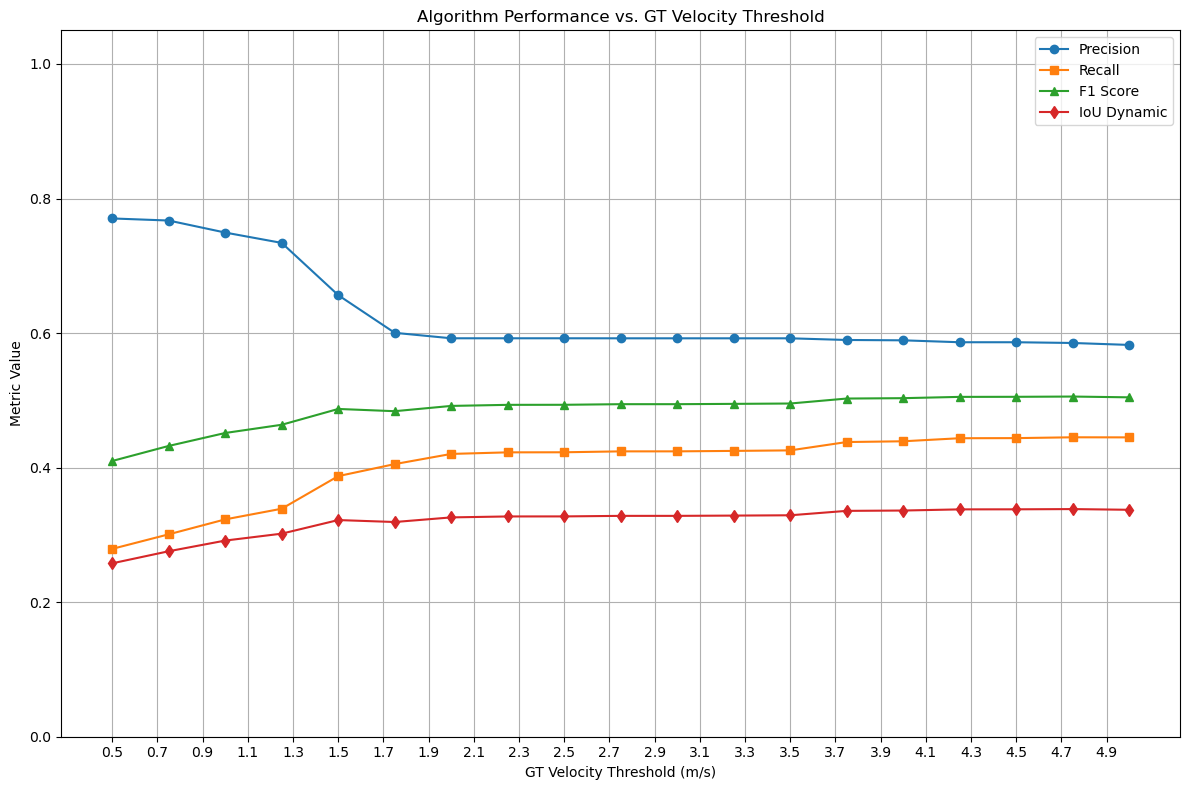


Cell 2: Metrics Plotting - OK


In [6]:

# --- Plotting the metrics ---
plt.figure(figsize=(12, 8)) # Adjust figure size as needed

plt.plot(gt_velocity_thresholds, precisions, marker='o', linestyle='-', label='Precision')
plt.plot(gt_velocity_thresholds, recalls, marker='s', linestyle='-', label='Recall')
plt.plot(gt_velocity_thresholds, f1_scores, marker='^', linestyle='-', label='F1 Score')
plt.plot(gt_velocity_thresholds, ious_dynamic, marker='d', linestyle='-', label='IoU Dynamic')

plt.title('Algorithm Performance vs. GT Velocity Threshold')
plt.xlabel('GT Velocity Threshold (m/s)')
plt.ylabel('Metric Value')
plt.legend() # Show legend to identify lines
plt.grid(True) # Add a grid for easier reading
plt.ylim(0, 1.05) # Set y-axis limits, typically metrics are between 0 and 1
plt.xticks(np.arange(min(gt_velocity_thresholds), max(gt_velocity_thresholds)+0.1, 0.2)) # Adjust x-axis ticks for clarity
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("\nCell 2: Metrics Plotting - OK")